# 반도체 공정 스케줄링 시뮬레이션 결과

## 환경 설정

In [2]:
import os
import simpy
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# .env 파일의 환경 변수 로드
load_dotenv(override=True)

# .env 파일의 파라미터
BASE_DATA_PATH = os.getenv('BASE_DATA_PATH', 'data')
PM_HAZARD_THRESHOLD = os.getenv('PM_HAZARD_THRESHOLD', '0.1')
QTIME_URGENCY_FACTOR = os.getenv('QTIME_URGENCY_FACTOR', '1.5')
PM_ACTIVE = os.getenv('PM_ACTIVE', 'True').lower() == 'true'
DOWN_ACTIVE = os.getenv('DOWN_ACTIVE', 'True').lower() == 'true'
JOB_RULE = os.getenv('JOB_RULE', 'random')
print(f"BASE_DATA_PATH: {BASE_DATA_PATH}")
print(f"PM_HAZARD_THRESHOLD: {PM_HAZARD_THRESHOLD}")
print(f"QTIME_URGENCY_FACTOR: {QTIME_URGENCY_FACTOR}")
print(f"PM_ACTIVE: {PM_ACTIVE}")
print(f"DOWN_ACTIVE: {DOWN_ACTIVE}")
print(f"JOB_RULE: {JOB_RULE}")

BASE_DATA_PATH: data
PM_HAZARD_THRESHOLD: 0.1
QTIME_URGENCY_FACTOR: 1.5
PM_ACTIVE: True
DOWN_ACTIVE: True
JOB_RULE: random


## 모듈 import

In [3]:
from utils import DataLoader, EventLogger
from utils.visualizer import create_gantt_chart
from simulation import Scheduler

## 데이터 로드

In [4]:
data_loader = DataLoader(BASE_DATA_PATH)

data = data_loader.load_all_data()

print("=" * 60)
print("데이터 개요")
print("=" * 60)
print(f"Jobs: {len(data['jobs'])} 개")
print(f"Operations: {len(data['operations'])} 개")
print(f"Machines: {len(data['machines'])} 개")
print(f"Machine Failures: {len(data['machine_failure'])} 개")
print(f"Setup Times: {len(data['setup_times'])} 개")
print(f"Operation-Machine Map: {len(data['operation_machine_map'])} 개")

데이터 개요
Jobs: 10 개
Operations: 35 개
Machines: 8 개
Machine Failures: 8 개
Setup Times: 12 개
Operation-Machine Map: 95 개


## 시뮬레이션 실행

In [5]:
import random
random.seed(42)

# SimPy 환경 생성
env = simpy.Environment()

# 이벤트 로거 생성
event_logger = EventLogger(env)

# 스케줄러 생성
scheduler = Scheduler(env=env,
                      data=data,
                      event_logger=event_logger,
                      pm_hazard_threshold=float(PM_HAZARD_THRESHOLD),
                      qtime_urgency_factor=float(QTIME_URGENCY_FACTOR))

In [6]:
env.run(until=scheduler.job_chk_process)
fig = create_gantt_chart(
    logs=event_logger.logs,
    max_time=env.now,
    title=f"반도체 공정 간트 차트 (Simulation Time: {round(env.now, 3)})")
fig.show()

## 시뮬레이션 KPI 및 통계

### 작업별 통계

In [7]:
scheduler.get_simulation_info()

Job ID: J1	완료 시간: 48
Job ID: J2	완료 시간: 40
Job ID: J3	완료 시간: 78
Job ID: J4	완료 시간: 132
Job ID: J5	완료 시간: 122
Job ID: J6	완료 시간: 119
Job ID: J7	완료 시간: 109
Job ID: J8	완료 시간: 107
Job ID: J9	완료 시간: 86
Job ID: J10	완료 시간: 91
시뮬레이션 시간: 132
총 작업 수: 10
완료된 작업 수: 10
기한 안에 완료된 작업 수: 10


waiting  setup  working  qtime_over job_type
id  op_id                                               
J1  J1_O1       0.0    0.0      8.0         0.0       P1
    J1_O2       0.0    0.0     15.0         0.0       P1
    J1_O3       4.0    0.0     12.0         0.0       P1
    J1_O4       0.0    0.0      9.0         0.0       P1
J10 J10_O1     12.0    0.0     22.0         0.0       P2
    J10_O2      0.0    0.0     12.0         0.0       P2
    J10_O3      0.0    0.0     15.0         0.0       P2
J2  J2_O1       0.0    0.0      8.0         0.0       P2
    J2_O2       0.0    0.0     24.0         0.0       P2
    J2_O3       0.0    0.0      8.0         0.0       P2
J3  J3_O1       0.0    0.0     15.0         0.0       P1
    J3_O2       9.0    0.0     22.0         0.0       P1
    J3_O3       7.0    0.0      8.0         0.0       P1
    J3_O4       0.0    0.0     12.0         0.0       P1
J4  J4_O1       3.0    0.0     14.0         0.0       P2
    J4_O2      79.0    0.0     10.0        67.0       P2
    J4_O3       2.0    0.0     19.0         0.0       P2
J5  J5_O1       0.0    0.0      9.0         0.0       P1
    J5_O2      51.0    0.0     25.0        36.0       P1
    J5_O3       0.0    0.0     10.0         0.0       P1
    J5_O4       0.0    0.0     17.0         0.0       P1
J6  J6_O1      24.0    4.0     10.0         0.0       P2
    J6_O2      45.0    0.0     10.0        31.0       P2
    J6_O3       0.0    0.0     11.0         0.0       P2
J7  J7_O1      14.0    0.0     19.0         0.0       P1
    J7_O2       4.0    0.0     13.0         0.0       P1
    J7_O3       0.0    0.0     14.0         0.0       P1
    J7_O4       0.0    0.0     25.0         0.0       P1
J8  J8_O1       4.0    0.0     13.0         0.0       P2
    J8_O2      39.0    0.0     16.0        21.0       P2
    J8_O3       0.0    0.0     15.0         0.0       P2
J9  J9_O1       0.0    0.0      9.0         0.0       P1
    J9_O2       4.0    0.0     20.0         0.0       P1
    J9_O3       0.0    0.0     14.0         0.0       P1
    J9_O4       0.0    0.0     14.0         0.0       P1

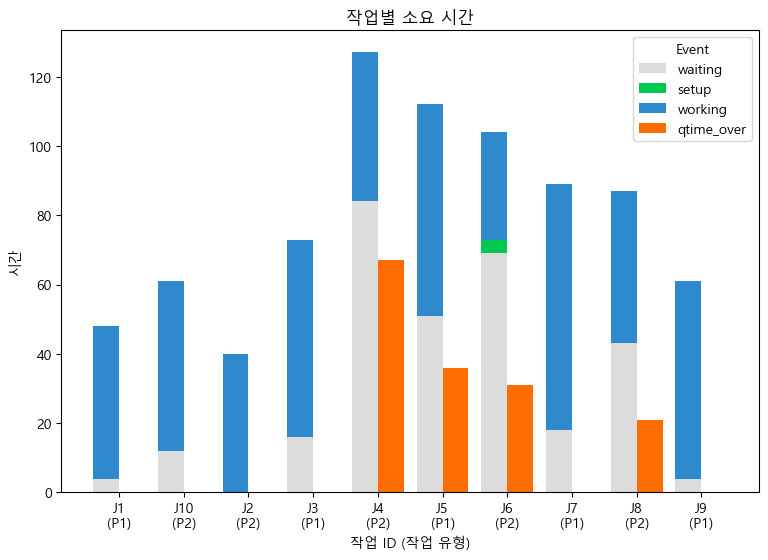

In [8]:
df_logs = pd.DataFrame(event_logger.logs)
job_info = df_logs[df_logs['resource'] == 'job']
job_info['duration'] = round(job_info['finish'] - job_info['start'], 3)
job_op_info = job_info.groupby(['id', 'op_id', 'event'], dropna=False)['duration'].sum().reset_index()
job_op_stacked = job_op_info.pivot(index=['id', 'op_id'], columns='event', values='duration').fillna(0)
job_op_stacked = job_op_stacked.reindex(columns=['waiting', 'setup', 'working', 'qtime_over'], fill_value=0)
job_type_map = data['jobs'].set_index('job_id')['job_type']
job_op_stacked = job_op_stacked.join(job_type_map, on='id')
display(job_op_stacked)

job_info_sum = job_info.groupby(['id', 'event'])['duration'].sum().reset_index(['id', 'event'], drop=False)
job_stacked = job_info_sum.pivot(index='id', columns='event', values='duration').fillna(0)
job_stacked = job_stacked.reindex(columns=['waiting', 'setup', 'working', 'qtime_over'], fill_value=0)
job_stacked = job_stacked.join(job_type_map)
job_stacked.index = [f"{i}\n({t})" for i, t in zip(job_stacked.index, job_stacked['job_type'])]
import numpy as np
fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(job_stacked))
width = 0.4

bottom = np.zeros(len(job_stacked))
for ev, color in zip(["waiting", "setup", "working"], ['#DCDCDC', '#00C853', '#2E89CD']):
    ax.bar(x - width/2, job_stacked[ev], width, label=ev, color=color, bottom=bottom)
    bottom += job_stacked[ev].values

ax.bar(x + width/2, job_stacked['qtime_over'], width, label='qtime_over', color='#FF6D00')

ax.set_xticks(x)
ax.set_xticklabels(job_stacked.index, rotation=0)
plt.title("작업별 소요 시간")
plt.xlabel("작업 ID (작업 유형)")
plt.ylabel("시간")
plt.legend(title="Event")
plt.show()

### 공정별 설비 활용률

,utilization,group
id,,
M1,0.393939,G1
M2,0.575758,G1
M3,0.431818,G1
M4,0.643939,G2
M5,0.621212,G2
M6,0.303030,G3
M7,0.303030,G3
M8,0.492424,G3


C:\Users\hun99\AppData\Local\Temp\ipykernel_26152\3678771107.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=machine_utilization, x='group', y='utilization',


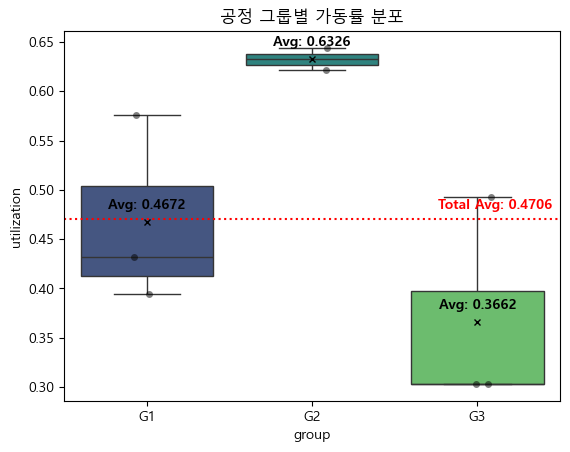

In [9]:

df_logs = pd.DataFrame(event_logger.logs)
machine_info = df_logs[df_logs['resource'] == 'machine']
machine_info['utilization'] = machine_info['finish'] - machine_info['start']
machine_utilization = pd.DataFrame(machine_info[machine_info['event'] == 'working'].groupby('id')['utilization'].sum() / env.now)
machine_utilization['group'] = data['machines'].set_index('machine_id').loc[machine_utilization.index]['machine_group']
display(machine_utilization)
group_means = machine_utilization.groupby('group')['utilization'].mean()
total_mean = machine_utilization['utilization'].mean()
sns.boxplot(data=machine_utilization, x='group', y='utilization', 
            palette='viridis', showmeans=True,
            meanprops={"marker":"x", "markeredgecolor":"black", "markersize":"5"})
sns.stripplot(data=machine_utilization, x='group', y='utilization', 
              color='black', alpha=0.5, jitter=True)
for i, group in enumerate(group_means.index):
    mean_val = group_means[group]
    plt.text(i, mean_val + 0.01, f'Avg: {mean_val:.4f}', 
             ha='center', va='bottom', color='black', fontweight='bold')
plt.text(len(group_means)-0.55, total_mean + 0.01, f'Total Avg: {total_mean:.4f}', color='red', fontweight='bold', ha='right')
plt.axhline(total_mean, color='red', linestyle=':')
plt.title("공정 그룹별 가동률 분포")
plt.show()

In [10]:
import importlib
import simulation, utils

def run_simulation(rule: str, seed: int = 42) -> dict:
    random.seed(seed)

    # 모듈 재로드 (셀 재실행 시 상태 초기화)
    importlib.reload(simulation)
    importlib.reload(utils)
    from simulation import Scheduler
    from utils import EventLogger

    os.environ['JOB_RULE'] = rule

    _env = simpy.Environment()
    _logger = EventLogger(_env)
    _scheduler = Scheduler(
        env=_env,
        data=data,
        event_logger=_logger,
        pm_hazard_threshold=float(PM_HAZARD_THRESHOLD),
        qtime_urgency_factor=float(QTIME_URGENCY_FACTOR),
    )
    _env.run(until=_scheduler.job_chk_process)

    completed, due_ok = 0, 0
    for job in _scheduler._Scheduler__jobs:
        completed += int(job.completed_time > 0.0)
        due_ok    += int(job.is_in_due_date())

    df_logs = pd.DataFrame(_logger.logs)
    qtime_rows = df_logs[
        (df_logs['resource'] == 'job') & (df_logs['event'] == 'qtime_over')
    ]
    qtime_total = round((qtime_rows['finish'] - qtime_rows['start']).sum(), 3)

    return {
        'rule':              rule,
        'makespan':          round(_env.now, 3),
        'completed_jobs':    completed,
        'due_date_met':      due_ok,
        'qtime_violation':   round(qtime_total, 3),
    }

RULES = ['random', 'FIFO', 'SPT', 'LPT', 'MIN_QTIME', 'SPTSSU']
results = [run_simulation(r) for r in RULES]

df_compare = pd.DataFrame(results).set_index('rule')
display(df_compare)

# 복원
os.environ['JOB_RULE'] = JOB_RULE

,makespan,completed_jobs,due_date_met,qtime_violation
rule,,,,
random,132.000,10,10,155.000
FIFO,172.570,10,8,173.000
SPT,152.000,10,9,136.787
LPT,152.000,10,10,183.000
MIN_QTIME,140.000,10,10,95.000
SPTSSU,149.539,10,9,130.787


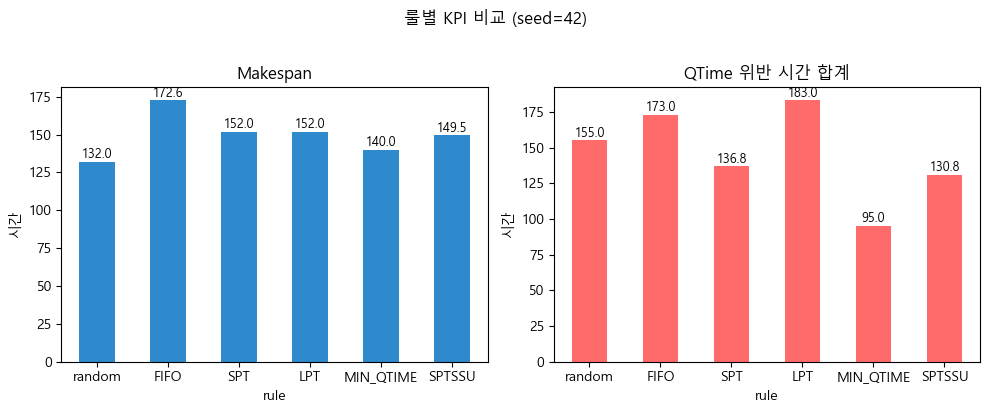

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df_compare['makespan'].plot(kind='bar', ax=axes[0], color='#2E89CD', rot=0)
axes[0].set_title('Makespan')
axes[0].set_ylabel('시간')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

df_compare['qtime_violation'].plot(kind='bar', ax=axes[1], color='#FF6B6B', rot=0)
axes[1].set_title('QTime 위반 시간 합계')
axes[1].set_ylabel('시간')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('룰별 KPI 비교 (seed=42)', y=1.02)
plt.tight_layout()
plt.show()